#Q1. What is a Common Table Expression (CTE), and how does it improve SQL query readability?
    ->A Common Table Expression (CTE) is a temporary result set that you define at the beginning of a SQL query using the WITH keyword. It acts like a named subquery that you can reuse within the main query.Basic Syntax:-
    SQL
    WITH cte_name AS (
        SELECT column1, column2
        FROM table_name
        WHERE condition
    )
    SELECT * FROM cte_name;
    
    Simple Example
    
    Without CTE:
    SQL
    SELECT name, salary
    FROM employees
    WHERE salary > (
        SELECT AVG(salary) FROM employees
    );
    
    With CTE:
    SQL
    WITH avg_salary_cte AS (
        SELECT AVG(salary) AS avg_salary FROM employees
    )
    SELECT name, salary
    FROM employees, avg_salary_cte
    WHERE employees.salary > avg_salary_cte.avg_salary;
    
    CTE Improves Readability by:-
    .Breaks complex queries into steps.
    .Instead of writing everything in one big query, you divide it into logical parts.
    .Makes code cleaner and easier to understand.
    .You give a name (avg_salary_cte) to a subquery, so it’s easier to read.
    .Avoids repetition.
    .If the same subquery is needed multiple times, you define it once and reuse it.
    .Better debugging.
    .You can test each part separately.
    .Supports recursion (advanced use).
    .Useful for hierarchical data (like employee-manager relationships).

    When to Use CTE :-
    .Complex queries with multiple joins.
    .When using subqueries multiple times.
    .Hierarchical data (tree structure).
    .Improving query clarity for interviews or production code.

#Q2. Why are some views updatable while others are read-only? Explain with an example.
    ->A view in SQL is a virtual table created from a query. Whether you can UPDATE / INSERT / DELETE through a view depends on how simple or complex that view is.

    1. Updatable Views (Editable Views)

    A view is updatable when SQL can clearly map changes back to a single base table.

    Conditions for Updatable View:

    Based on one table only

    .No JOIN

    .No GROUP BY

    .No aggregate functions (SUM, COUNT, AVG)

    .No DISTINCT

    .Includes primary key (recommended)


    Example (Updatable View)

    CREATE VIEW employee_view AS
    SELECT id, name, salary
    FROM employees;

    Now we can do:

    UPDATE employee_view
    SET salary = 50000
    WHERE id = 1;

    This works because it directly maps to the employees table.

    2.Read-Only Views (Non-Updatable)

    A view becomes read-only when SQL cannot determine how to apply changes to underlying tables.

    Conditions for Read-Only View:

    .Uses JOIN

    .Uses GROUP BY

    .Uses aggregate functions (SUM, AVG, COUNT)

    .Uses DISTINCT

    .Uses UNION

    Example(Read-Only View)

    CREATE VIEW employee_dept_view AS
    SELECT e.name, d.department_name
    FROM employees e
    JOIN departments d ON e.dept_id = d.id;

    Now if we try:

    UPDATE employee_dept_view
    SET name = 'Rajat'
    WHERE department_name = 'IT';

    This will fail because SQL doesn't know.

#Q3. What advantages do stored procedures offer compared to writing raw SQL queries repeatedly?
    ->A stored procedure is a precompiled SQL program stored in the database that can be executed multiple times.

    Advantages:

    1.Reusability – Write once, use many times.
    2.Better Performance – Precompiled, executes faster
    3.Security – Users can execute procedure without accessing tables directly.
    4.Reduced Code Duplication – No need to write same query again.
    5.Supports Business Logic – Can use conditions, loops, parameters.

    Example:

    CREATE PROCEDURE GetEmployees(IN dept VARCHAR(50))
    BEGIN
      SELECT * FROM employees WHERE department = dept;
    END;

    CALL GetEmployees('IT');


    Conclusion:

    Stored procedures improve performance, security, and maintainability of database operations.

#Q4. What is the purpose of triggers in a database? Mention one use case where a trigger is essential.
    -> A trigger is a special type of stored program in SQL that is automatically executed (or “fired”) when a specific event occurs on a table, such as INSERT, UPDATE, or DELETE.

    Types of Triggers:

    1.BEFORE Trigger – Executes before the event.
    2.AFTER Trigger – Executes after the event.

    Advantages:

    .Automatically enforces rules.
    .Maintains data integrity.
    .Useful for logging and auditing changes.

    Example:

    CREATE TRIGGER after_insert_employee
    AFTER INSERT ON employees
    FOR EACH ROW
    BEGIN
      INSERT INTO audit_log(employee_id, action)
      VALUES (NEW.id, 'Employee Added');
    END;

    Explanation:

    .When a new record is inserted into the employees table.
    .The trigger automatically inserts a record into audit_log.
    .This helps in tracking changes.

    Conclusion:
    Triggers are used to automatically perform actions in response to database events, ensuring data consistency and auditing.


#Q5. Explain the need for data modelling and normalization when designing a database.
    ->Normalization is the process of organizing data in a database to reduce redundancy and improve data integrity.

    Objectives of Normalization:-
    .Remove duplicate data
    .Ensure data consistency
    .Improve database structure

    Types of Normalization:

    1.First Normal Form (1NF)
    .No repeating groups or multiple values in a column.
    .Each field contains atomic (single) values.

    Example:
    It will store in Subjects in separate rows.

    2. Second Normal Form (2NF)
    .Must be in 1NF
    .No partial dependency (non-key columns depend on full primary key)

    3. Third Normal Form (3NF)
    .Must be in 2NF.
    .No transitive dependency (non-key columns depend only on primary key).
    
    Example:-
    .Before Normalization:
    .Student(ID, Name, Course, Instructor)

    After 3NF:
    Student(ID, Name).
    Course(CourseID, CourseName).
    Instructor(InstructorID, Name).

    Advantages:
    .Reduces data redundancy
    .Improves data consistency
    .Easier data maintenance

    Conclusion:-
    Normalization helps in designing a well-structured database by eliminating redundancy and ensuring data dependency is logical.

#Q6. Write a CTE to calculate the total revenue for each product.(Revenues = Price × Quantity), and return only products where  revenue > 3000.
 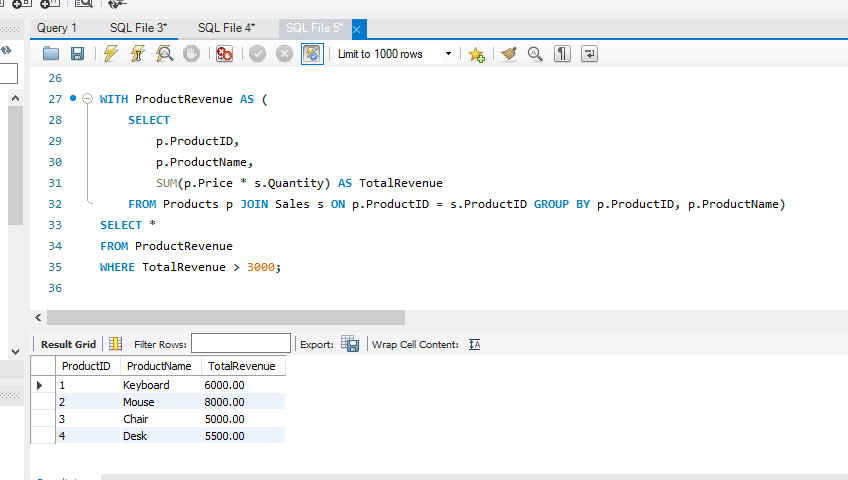
#Q7. Create a view named that shows:Category TotalProducts, AveragePrice.
    -> CREATE VIEW vw_CategorySummary AS
    SELECT
    Category,
    COUNT(*) AS TotalProducts,
    AVG(Price) AS AveragePrice
    FROM Products
    GROUP BY Category;
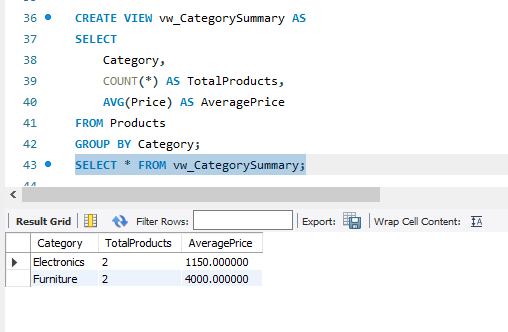   

#Q8. Create an updatable view containing ProductID, ProductName, and Price.Then update the price of ProductID = 1 using the view.
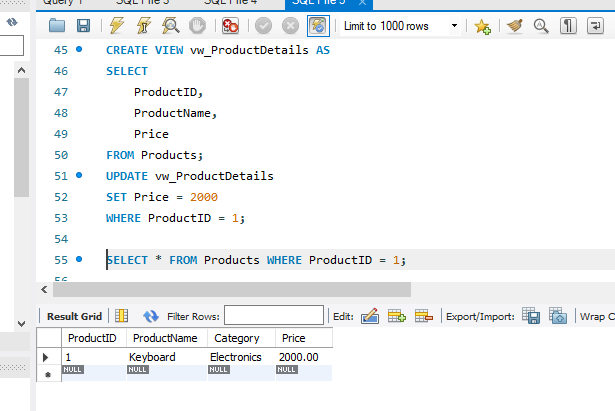

#9.Create a stored procedure that accepts a category name and returns all products belonging to that category.
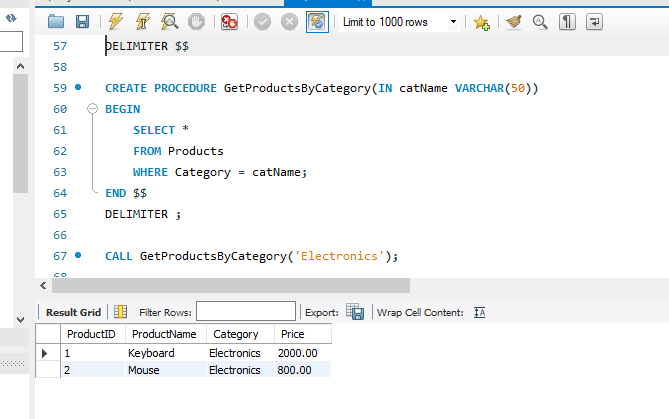

#10.Create an AFTER DELETE trigger on the Products table that archives deleted product rows into a new table ProductArchive . The archive should store ProductID, ProductName, Category, Price, and DeletedAt timestamp.
    ->CREATE TABLE Products_Archive (
    ProductID INT,ProductName VARCHAR(100),Category VARCHAR(50),Price DECIMAL(10,2),
    DeletedAt TIMESTAMP DEFAULT CURRENT_TIMESTAMP);
    
    DELIMITER $$

    CREATE TRIGGER before_product_delete
    BEFORE DELETE ON Products
    FOR EACH ROW
    BEGIN
    INSERT INTO Products_Archive (ProductID, ProductName, Category, Price)
    VALUES (OLD.ProductID, OLD.ProductName, OLD.Category, OLD.Price);
    END $$

    DELIMITER ;
    DELETE FROM Products WHERE ProductID = 1;